<a href="https://colab.research.google.com/github/dimitarpg13/agentic_architectures_and_design_patterns/blob/main/notebooks/task_driven_load_distribution/web_search_example_via_worker_pool_and_semaphore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏊 Worker Pool with Semaphore Pattern for Multi-Agent Workflows

This notebook demonstrates the **Worker Pool with Semaphore** design pattern using LangGraph, featuring:
- **Orchestrator Agent**: Creates tasks and assigns them to the worker pool
- **Worker Pool**: Fixed pool of workers controlled by a semaphore
- **Semaphore**: Controls concurrent access to limit parallel execution

## Architecture

```
┌──────────────────────────────────────────────────────────────────────────┐
│                    WORKER POOL WITH SEMAPHORE                            │
├──────────────────────────────────────────────────────────────────────────┤
│                                                                          │
│  ┌─────────────────┐                                                     │
│  │   User Query    │                                                     │
│  └────────┬────────┘                                                     │
│           │                                                              │
│           ▼                                                              │
│  ┌─────────────────┐                                                     │
│  │  ORCHESTRATOR   │                                                     │
│  │     AGENT       │                                                     │
│  │                 │                                                     │
│  │ • Analyze query │                                                     │
│  │ • Create tasks  │                                                     │
│  │ • Submit to pool│                                                     │
│  └────────┬────────┘                                                     │
│           │                                                              │
│           │  submit tasks                                                │
│           ▼                                                              │
│  ┌─────────────────────────────────────────────────────┐                │
│  │              WORKER POOL (Semaphore-Controlled)      │                │
│  │  ┌─────────────────────────────────────────────────┐ │                │
│  │  │           🚦 SEMAPHORE (max_workers=3)          │ │                │
│  │  │  ┌─────────┐  ┌─────────┐  ┌─────────┐          │ │                │
│  │  │  │ Slot 1  │  │ Slot 2  │  │ Slot 3  │  ...     │ │                │
│  │  │  │ Worker  │  │ Worker  │  │ Worker  │          │ │                │
│  │  │  └────┬────┘  └────┬────┘  └────┬────┘          │ │                │
│  │  └───────┼────────────┼────────────┼───────────────┘ │                │
│  │          │            │            │                  │                │
│  │          └────────────┼────────────┘                  │                │
│  │                       ▼                               │                │
│  │              [Concurrent Search]                      │                │
│  └──────────────────────┬────────────────────────────────┘                │
│                         │                                                │
│                         ▼                                                │
│                ┌─────────────────┐                                       │
│                │ Result Aggregator│                                      │
│                │   (Synthesizer)  │                                      │
│                └────────┬─────────┘                                      │
│                         │                                                │
│                         ▼                                                │
│                ┌─────────────────┐                                       │
│                │  Final Report   │                                       │
│                └─────────────────┘                                       │
└──────────────────────────────────────────────────────────────────────────┘
```

## Key Features
- **Worker Pool Pattern**: Fixed pool of reusable workers
- **Semaphore Control**: Limits concurrent execution
- **Async Parallel Processing**: True parallel execution with threads
- **Resource Management**: Controlled resource usage

## Comparison: Task Queue vs Worker Pool + Semaphore

| Aspect | Task Queue | Worker Pool + Semaphore |
|--------|------------|------------------------|
| **Pattern** | Producer-Consumer | Pool-based execution |
| **Task Distribution** | Workers pull tasks | Tasks pushed to pool |
| **Concurrency Control** | Queue size | Semaphore count |
| **Parallelism** | Sequential per round | True parallel |
| **Worker Lifecycle** | Stateless per task | Managed by pool |

## 1. Environment Setup

In [1]:
# Install required packages
%pip install -q langchain langchain-openai langchain-anthropic langgraph tavily-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.9/405.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 496.3/496.3 kB 7.6 MB/s eta 0:00:00


In [2]:
import os
import time
from threading import Semaphore, Lock
from concurrent.futures import ThreadPoolExecutor
from typing import List, Dict, Any, Optional, Literal, TypedDict
from dataclasses import dataclass, field
from datetime import datetime
from enum import Enum
import uuid

# LangChain imports
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# LangGraph imports
from langgraph.graph import StateGraph, END, START

# Web search
from tavily import TavilyClient

print("✅ All imports successful!")

✅ All imports successful!


## 2. API Configuration

In [3]:
from getpass import getpass

# Choose your LLM provider
LLM_PROVIDER = "openai"  # Options: "openai", "anthropic"

# Set API keys
if LLM_PROVIDER == "openai" and "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")
elif LLM_PROVIDER == "anthropic" and "ANTHROPIC_API_KEY" not in os.environ:
    os.environ["ANTHROPIC_API_KEY"] = getpass("Enter your Anthropic API key: ")

if "TAVILY_API_KEY" not in os.environ:
    os.environ["TAVILY_API_KEY"] = getpass("Enter your Tavily API key: ")

print(f"✅ Configured for {LLM_PROVIDER.upper()} with Tavily web search")

Enter your OpenAI API key: ··········
Enter your Tavily API key: ··········
✅ Configured for OPENAI with Tavily web search


## 3. Initialize LLM and Tavily

In [4]:
def get_llm(provider: str = "openai", temperature: float = 0.7):
    """Initialize the LLM based on the selected provider."""
    if provider == "openai":
        from langchain_openai import ChatOpenAI
        return ChatOpenAI(model="gpt-4o", temperature=temperature)
    elif provider == "anthropic":
        from langchain_anthropic import ChatAnthropic
        return ChatAnthropic(model="claude-sonnet-4-20250514", temperature=temperature)
    else:
        raise ValueError(f"Unknown provider: {provider}")

# Initialize LLM
llm = get_llm(LLM_PROVIDER)

# Initialize Tavily client
tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

print(f"✅ LLM initialized: {LLM_PROVIDER}")
print("✅ Tavily client initialized")

✅ LLM initialized: openai
✅ Tavily client initialized


## 4. Define Worker Pool and Data Structures

The worker pool uses a semaphore to control the maximum number of concurrent workers.

In [5]:
class TaskStatus(str, Enum):
    """Status of a task."""
    PENDING = "pending"
    IN_PROGRESS = "in_progress"
    COMPLETED = "completed"
    FAILED = "failed"


@dataclass
class SearchTask:
    """Represents a single search task."""
    task_id: str
    query: str
    priority: int = 1
    status: TaskStatus = TaskStatus.PENDING
    assigned_worker: Optional[str] = None
    result: Optional[str] = None
    error: Optional[str] = None
    created_at: str = field(default_factory=lambda: datetime.now().isoformat())
    completed_at: Optional[str] = None


class WorkerPool:
    """Thread-safe worker pool with semaphore-controlled concurrency.

    This implements the Worker Pool pattern where:
    - A fixed number of workers are available in the pool
    - A semaphore controls how many can execute concurrently
    - Tasks are submitted and executed in parallel up to the limit
    """

    def __init__(self, max_workers: int = 3):
        """Initialize the worker pool.

        Args:
            max_workers: Maximum number of concurrent workers (semaphore limit)
        """
        self.max_workers = max_workers
        self._semaphore = Semaphore(max_workers)
        self._lock = Lock()
        self._tasks: Dict[str, SearchTask] = {}
        self._results: List[Dict[str, Any]] = []
        self._active_workers = 0
        self._executor = ThreadPoolExecutor(max_workers=max_workers)

        print(f"   🏊 Worker Pool created with max {max_workers} concurrent workers")

    def acquire_worker(self) -> bool:
        """Acquire a worker slot from the semaphore.

        Returns:
            True if a worker slot was acquired
        """
        acquired = self._semaphore.acquire(blocking=False)
        if acquired:
            with self._lock:
                self._active_workers += 1
        return acquired

    def release_worker(self) -> None:
        """Release a worker slot back to the semaphore."""
        with self._lock:
            self._active_workers -= 1
        self._semaphore.release()

    def get_active_count(self) -> int:
        """Get the number of currently active workers."""
        with self._lock:
            return self._active_workers

    def get_available_slots(self) -> int:
        """Get the number of available worker slots."""
        with self._lock:
            return self.max_workers - self._active_workers

    def register_task(self, task: SearchTask) -> None:
        """Register a task with the pool."""
        with self._lock:
            self._tasks[task.task_id] = task

    def add_result(self, task_id: str, worker_id: str, result: str) -> None:
        """Add a result for a completed task."""
        with self._lock:
            if task_id in self._tasks:
                self._tasks[task_id].status = TaskStatus.COMPLETED
                self._tasks[task_id].result = result
                self._tasks[task_id].assigned_worker = worker_id
                self._tasks[task_id].completed_at = datetime.now().isoformat()
            self._results.append({
                "task_id": task_id,
                "worker_id": worker_id,
                "query": self._tasks[task_id].query if task_id in self._tasks else "",
                "result": result
            })

    def mark_failed(self, task_id: str, error: str) -> None:
        """Mark a task as failed."""
        with self._lock:
            if task_id in self._tasks:
                self._tasks[task_id].status = TaskStatus.FAILED
                self._tasks[task_id].error = error
                self._tasks[task_id].completed_at = datetime.now().isoformat()

    def get_all_results(self) -> List[Dict[str, Any]]:
        """Get all completed results."""
        with self._lock:
            return self._results.copy()

    def get_stats(self) -> Dict[str, int]:
        """Get pool statistics."""
        with self._lock:
            return {
                "total_tasks": len(self._tasks),
                "active_workers": self._active_workers,
                "available_slots": self.max_workers - self._active_workers,
                "completed": sum(1 for t in self._tasks.values() if t.status == TaskStatus.COMPLETED),
                "failed": sum(1 for t in self._tasks.values() if t.status == TaskStatus.FAILED),
                "pending": sum(1 for t in self._tasks.values() if t.status == TaskStatus.PENDING),
            }

    def shutdown(self) -> None:
        """Shutdown the worker pool."""
        self._executor.shutdown(wait=True)
        print("   🛑 Worker Pool shut down")


print("✅ Worker Pool class defined")

✅ Worker Pool class defined


## 5. Define Workflow State

In [6]:
class WorkflowState(TypedDict):
    """State for the worker pool workflow.

    Attributes:
        user_query: The original user query
        max_workers: Maximum concurrent workers (semaphore limit)
        tasks: List of tasks to execute
        worker_results: Results collected from workers
        final_report: Synthesized final report
        phase: Current phase of the workflow
    """
    user_query: str
    max_workers: int
    tasks: List[SearchTask]
    worker_results: List[Dict[str, Any]]
    final_report: str
    phase: str
    tasks_created: int
    tasks_completed: int


print("✅ Workflow state defined")

✅ Workflow state defined


## 6. Web Search Function

In [7]:
def perform_web_search(query: str, max_results: int = 5) -> str:
    """Perform a web search using Tavily API.

    Args:
        query: The search query
        max_results: Maximum number of results

    Returns:
        Formatted search results
    """
    try:
        response = tavily_client.search(
            query=query,
            search_depth="advanced",
            max_results=max_results,
            include_answer=True,
        )

        results = []

        if response.get("answer"):
            results.append(f"**Summary:** {response['answer']}\n")

        results.append("**Sources:**")
        for i, r in enumerate(response.get("results", []), 1):
            title = r.get("title", "No title")
            url = r.get("url", "")
            content = r.get("content", "")[:250]
            results.append(f"{i}. **{title}**\n   {url}\n   {content}...\n")

        return "\n".join(results)

    except Exception as e:
        return f"Search error: {str(e)}"


# Test search
print("Testing Tavily search...")
test_result = perform_web_search("LangGraph multi-agent", max_results=2)
print(f"✅ Search working. Preview:\n{test_result[:300]}...")

Testing Tavily search...
✅ Search working. Preview:
**Summary:** LangGraph is a framework for building multi-agent systems that maintain conversation state. It uses agents to handle different tasks, routing queries to the most suitable agent. The system can dynamically adapt based on the input context.

**Sources:**
1. **Building Multi-Agent Systems ...


## 7. Define Agent Prompts

In [8]:
ORCHESTRATOR_PROMPT = """You are a task orchestrator. Your job is to analyze a user query and
decompose it into specific, independent search tasks that can be executed in parallel.

User Query: {query}

Break this down into 3-5 specific search queries. Each query should:
- Focus on a distinct aspect of the topic
- Be specific enough to get relevant search results
- Be independent (not dependent on results from other queries)

Return ONLY a numbered list of search queries, one per line:
1. First specific search query
2. Second specific search query
3. Third specific search query
...
"""

SYNTHESIZER_PROMPT = """You are an expert at synthesizing research findings.

Original Query: {query}

Search Results from Multiple Workers:
{results}

Create a comprehensive report with:
1. **Executive Summary** - Key findings in 2-3 sentences
2. **Main Findings** - Organized by topic
3. **Key Insights** - Important takeaways
4. **Conclusion** - Summary and recommendations

Be specific and cite information from the search results.
"""

print("✅ Prompts defined")

✅ Prompts defined


## 8. Define Semaphore-Controlled Worker Execution

This is the core of the worker pool pattern - workers are controlled by a semaphore.

In [9]:
# Global worker pool instance
worker_pool: Optional[WorkerPool] = None


def execute_task_with_semaphore(task: SearchTask, worker_id: str, pool: WorkerPool) -> Dict[str, Any]:
    """Execute a single task while holding a semaphore slot.

    This function:
    1. Acquires a semaphore slot (blocks if pool is full)
    2. Executes the search task
    3. Releases the semaphore slot

    Args:
        task: The search task to execute
        worker_id: Identifier for this worker execution
        pool: The worker pool managing the semaphore

    Returns:
        Result dictionary with task outcome
    """
    # Acquire semaphore slot (will block if all slots are taken)
    pool._semaphore.acquire()

    with pool._lock:
        pool._active_workers += 1
        active = pool._active_workers

    print(f"   🚦 {worker_id} acquired semaphore slot (active: {active}/{pool.max_workers})")
    print(f"      📝 Task: {task.query[:50]}...")

    task.status = TaskStatus.IN_PROGRESS
    task.assigned_worker = worker_id

    try:
        # Execute web search
        result = perform_web_search(task.query)

        # Store result
        pool.add_result(task.task_id, worker_id, result)

        print(f"      ✅ {worker_id} completed task")

        return {
            "task_id": task.task_id,
            "query": task.query,
            "result": result,
            "worker_id": worker_id,
            "status": "completed"
        }

    except Exception as e:
        pool.mark_failed(task.task_id, str(e))
        print(f"      ❌ {worker_id} failed: {str(e)}")

        return {
            "task_id": task.task_id,
            "query": task.query,
            "error": str(e),
            "worker_id": worker_id,
            "status": "failed"
        }

    finally:
        # Always release the semaphore slot
        with pool._lock:
            pool._active_workers -= 1
            active = pool._active_workers
        pool._semaphore.release()
        print(f"   🚦 {worker_id} released semaphore slot (active: {active}/{pool.max_workers})")


print("✅ Semaphore-controlled execution defined")

✅ Semaphore-controlled execution defined


## 9. Define Workflow Nodes

### Orchestrator Agent
The orchestrator creates tasks and prepares them for the worker pool.

In [10]:
def orchestrator_agent(state: WorkflowState) -> WorkflowState:
    """Orchestrator agent that creates tasks for the worker pool.

    This agent:
    1. Analyzes the user query
    2. Decomposes it into independent search tasks
    3. Prepares tasks for submission to the worker pool
    """
    global worker_pool

    print("\n" + "="*60)
    print("🎯 ORCHESTRATOR AGENT: Creating tasks for worker pool")
    print("="*60)

    query = state["user_query"]

    # Use LLM to decompose the query into tasks
    prompt = ChatPromptTemplate.from_template(ORCHESTRATOR_PROMPT)
    chain = prompt | llm | StrOutputParser()
    decomposed = chain.invoke({"query": query})

    print(f"\n📋 Decomposed query into tasks:")

    # Parse and create tasks
    lines = [line.strip() for line in decomposed.strip().split("\n") if line.strip()]
    tasks = []

    for line in lines:
        # Remove numbering
        if line[0].isdigit() and "." in line[:3]:
            query_text = line.split(".", 1)[1].strip()
        else:
            query_text = line

        if query_text:
            task = SearchTask(
                task_id=str(uuid.uuid4())[:8],
                query=query_text,
                priority=1
            )
            tasks.append(task)
            worker_pool.register_task(task)
            print(f"   📝 Created: {task.task_id} - {query_text[:40]}...")

    print(f"\n✅ Orchestrator created {len(tasks)} tasks")
    print(f"   Pool capacity: {worker_pool.max_workers} concurrent workers")

    return {
        **state,
        "tasks": tasks,
        "phase": "workers",
        "tasks_created": len(tasks),
    }


print("✅ Orchestrator agent defined")

✅ Orchestrator agent defined


### Worker Pool Execution
Submit all tasks to the worker pool for parallel execution controlled by semaphore.

In [11]:
def worker_pool_execute(state: WorkflowState) -> WorkflowState:
    """Execute all tasks using the worker pool with semaphore control.

    This function:
    1. Submits all tasks to the thread pool executor
    2. Semaphore controls how many execute concurrently
    3. Collects all results when complete
    """
    global worker_pool

    print("\n" + "="*60)
    print("🏊 WORKER POOL: Executing tasks with semaphore control")
    print(f"   🚦 Semaphore limit: {worker_pool.max_workers} concurrent workers")
    print("="*60)

    tasks = state["tasks"]

    # Submit all tasks to the thread pool
    # The semaphore inside execute_task_with_semaphore controls concurrency
    futures = []

    print(f"\n📤 Submitting {len(tasks)} tasks to worker pool...\n")

    for i, task in enumerate(tasks):
        worker_id = f"worker_{i+1}"
        future = worker_pool._executor.submit(
            execute_task_with_semaphore,
            task,
            worker_id,
            worker_pool
        )
        futures.append(future)

    # Wait for all tasks to complete and collect results
    worker_results = []
    tasks_completed = 0

    print("\n⏳ Waiting for all workers to complete...\n")

    for future in futures:
        result = future.result()  # This blocks until the task completes
        worker_results.append(result)
        if result.get("status") == "completed":
            tasks_completed += 1

    stats = worker_pool.get_stats()
    print(f"\n📊 Pool Stats: {stats}")

    return {
        **state,
        "worker_results": worker_results,
        "tasks_completed": tasks_completed,
        "phase": "aggregate",
    }


print("✅ Worker pool execution defined")

✅ Worker pool execution defined


### Result Aggregator
Synthesizes all worker results into a final report.

In [12]:
def result_aggregator(state: WorkflowState) -> WorkflowState:
    """Aggregate and synthesize results from all workers."""
    print("\n" + "="*60)
    print("📊 RESULT AGGREGATOR: Synthesizing findings")
    print("="*60)

    worker_results = state["worker_results"]
    user_query = state["user_query"]

    # Format results for synthesis
    formatted_results = []
    for r in worker_results:
        if r.get("result"):
            formatted_results.append(
                f"### Search Query: {r['query']}\n"
                f"**Worker:** {r['worker_id']}\n\n"
                f"{r['result']}\n\n"
                f"---\n"
            )

    all_results = "\n".join(formatted_results)

    # Use LLM to synthesize
    prompt = ChatPromptTemplate.from_template(SYNTHESIZER_PROMPT)
    chain = prompt | llm | StrOutputParser()

    final_report = chain.invoke({
        "query": user_query,
        "results": all_results,
    })

    print(f"\n✅ Report synthesized ({len(final_report)} characters)")

    return {
        **state,
        "final_report": final_report,
        "phase": "complete",
    }


print("✅ Result aggregator defined")

✅ Result aggregator defined


## 10. Build the LangGraph Workflow

In [13]:
def build_worker_pool_workflow():
    """Build the worker pool workflow with semaphore control."""

    workflow = StateGraph(WorkflowState)

    # Add nodes
    workflow.add_node("orchestrator", orchestrator_agent)
    workflow.add_node("worker_pool", worker_pool_execute)
    workflow.add_node("aggregate", result_aggregator)

    # Define edges
    # Start -> Orchestrator (creates tasks)
    workflow.add_edge(START, "orchestrator")

    # Orchestrator -> Worker Pool (executes all tasks in parallel)
    workflow.add_edge("orchestrator", "worker_pool")

    # Worker Pool -> Aggregate (all tasks complete)
    workflow.add_edge("worker_pool", "aggregate")

    # Aggregate -> End
    workflow.add_edge("aggregate", END)

    return workflow.compile()


# Build the workflow
app = build_worker_pool_workflow()

print("✅ Workflow built successfully!")
print("\nWorkflow: START → Orchestrator → Worker Pool (parallel) → Aggregate → END")

✅ Workflow built successfully!

Workflow: START → Orchestrator → Worker Pool (parallel) → Aggregate → END


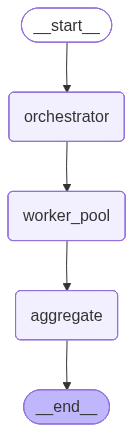

In [14]:
# Visualize the workflow (optional)
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph visualization:")
    print("""
    ┌───────────────┐
    │     START     │
    └───────┬───────┘
            │
            ▼
    ┌───────────────┐
    │  Orchestrator │ ──► Creates tasks
    └───────┬───────┘
            │
            ▼
    ┌───────────────────────────────┐
    │        Worker Pool            │
    │   🚦 Semaphore-Controlled     │
    │                               │
    │  ┌─────┐ ┌─────┐ ┌─────┐     │
    │  │ W1  │ │ W2  │ │ W3  │ ... │ ──► Parallel execution
    │  └─────┘ └─────┘ └─────┘     │
    └───────────┬───────────────────┘
                │
                ▼
    ┌───────────────┐
    │   Aggregate   │ ──► Synthesize results
    └───────┬───────┘
            │
            ▼
    ┌───────────────┐
    │      END      │
    └───────────────┘
    """)

## 11. Run the System

In [15]:
def run_worker_pool_search(query: str, max_workers: int = 3):
    """Run a distributed search using the worker pool with semaphore pattern.

    Args:
        query: The research query
        max_workers: Maximum number of concurrent workers (semaphore limit)

    Returns:
        Final state with results
    """
    global worker_pool

    # Create a new worker pool for this run
    worker_pool = WorkerPool(max_workers=max_workers)

    print("\n" + "="*80)
    print("🏊 WORKER POOL WITH SEMAPHORE PATTERN")
    print("="*80)
    print(f"\n📌 Query: {query}")
    print(f"🚦 Max concurrent workers (semaphore): {max_workers}")
    print("="*80)

    # Initialize state
    initial_state: WorkflowState = {
        "user_query": query,
        "max_workers": max_workers,
        "tasks": [],
        "worker_results": [],
        "final_report": "",
        "phase": "orchestrator",
        "tasks_created": 0,
        "tasks_completed": 0,
    }

    # Run the workflow
    final_state = app.invoke(initial_state)

    # Display summary
    print("\n" + "="*80)
    print("📊 EXECUTION SUMMARY")
    print("="*80)
    stats = worker_pool.get_stats()
    print(f"\n   Tasks created: {final_state['tasks_created']}")
    print(f"   Tasks completed: {stats['completed']}")
    print(f"   Tasks failed: {stats['failed']}")
    print(f"   Max concurrent workers: {max_workers}")

    # Worker statistics
    worker_stats = {}
    for r in final_state["worker_results"]:
        wid = r["worker_id"]
        worker_stats[wid] = worker_stats.get(wid, 0) + 1

    print("\n   Worker Statistics:")
    for wid, count in sorted(worker_stats.items()):
        print(f"   🤖 {wid}: {count} tasks completed")

    print("\n" + "="*80)
    print("📄 FINAL REPORT")
    print("="*80)
    print(final_state["final_report"])

    # Cleanup
    worker_pool.shutdown()

    return final_state

### Example 1: AI Agents Research

In [16]:
result1 = run_worker_pool_search(
    query="What are the latest developments in AI agents and multi-agent systems?",
    max_workers=3
)

   🏊 Worker Pool created with max 3 concurrent workers

🏊 WORKER POOL WITH SEMAPHORE PATTERN

📌 Query: What are the latest developments in AI agents and multi-agent systems?
🚦 Max concurrent workers (semaphore): 3

🎯 ORCHESTRATOR AGENT: Creating tasks for worker pool

📋 Decomposed query into tasks:
   📝 Created: 0169c17c - Recent advancements in AI agents technol...
   📝 Created: 28bd9cff - Current trends in multi-agent systems re...
   📝 Created: 125d3b9c - Latest applications of AI agents in indu...
   📝 Created: d31744c9 - New algorithms and techniques in multi-a...
   📝 Created: 438b15fe - Challenges and solutions in developing A...

✅ Orchestrator created 5 tasks
   Pool capacity: 3 concurrent workers

🏊 WORKER POOL: Executing tasks with semaphore control
   🚦 Semaphore limit: 3 concurrent workers

📤 Submitting 5 tasks to worker pool...

   🚦 worker_1 acquired semaphore slot (active: 1/3)
      📝 Task: Recent advancements in AI agents technology 2023...
   🚦 worker_2 acquired sema

### Example 2: Technology Comparison (Higher Concurrency)

In [17]:
result2 = run_worker_pool_search(
    query="Compare LangGraph vs AutoGen vs CrewAI for building multi-agent systems",
    max_workers=5  # Higher concurrency
)

   🏊 Worker Pool created with max 5 concurrent workers

🏊 WORKER POOL WITH SEMAPHORE PATTERN

📌 Query: Compare LangGraph vs AutoGen vs CrewAI for building multi-agent systems
🚦 Max concurrent workers (semaphore): 5

🎯 ORCHESTRATOR AGENT: Creating tasks for worker pool

📋 Decomposed query into tasks:
   📝 Created: 259ed80f - "LangGraph features and capabilities for...
   📝 Created: e64a63f5 - "AutoGen features and capabilities for b...
   📝 Created: b960bd27 - "CrewAI features and capabilities for bu...
   📝 Created: 39a61905 - "Comparison of LangGraph, AutoGen, and C...
   📝 Created: f0f09203 - "User reviews and case studies of LangGr...

✅ Orchestrator created 5 tasks
   Pool capacity: 5 concurrent workers

🏊 WORKER POOL: Executing tasks with semaphore control
   🚦 Semaphore limit: 5 concurrent workers

📤 Submitting 5 tasks to worker pool...

   🚦 worker_1 acquired semaphore slot (active: 1/5)
      📝 Task: "LangGraph features and capabilities for building ...
   🚦 worker_2 acquired s

### Example 3: Limited Concurrency Demo

In [18]:
# Try with limited concurrency to see semaphore in action
result3 = run_worker_pool_search(
    query="What are the best practices for implementing RAG systems?",
    max_workers=2  # Lower concurrency to see queueing
)

   🏊 Worker Pool created with max 2 concurrent workers

🏊 WORKER POOL WITH SEMAPHORE PATTERN

📌 Query: What are the best practices for implementing RAG systems?
🚦 Max concurrent workers (semaphore): 2

🎯 ORCHESTRATOR AGENT: Creating tasks for worker pool

📋 Decomposed query into tasks:
   📝 Created: e2bc94a9 - Best practices for integrating retrieval...
   📝 Created: 9b69e7de - Effective data retrieval techniques for ...
   📝 Created: b8369298 - Common challenges and solutions in imple...
   📝 Created: 2f9d0a0b - Tools and frameworks commonly used for b...
   📝 Created: b81dbb68 - Evaluating the performance of RAG system...

✅ Orchestrator created 5 tasks
   Pool capacity: 2 concurrent workers

🏊 WORKER POOL: Executing tasks with semaphore control
   🚦 Semaphore limit: 2 concurrent workers

📤 Submitting 5 tasks to worker pool...

   🚦 worker_1 acquired semaphore slot (active: 1/2)
      📝 Task: Best practices for integrating retrieval-augmented...
   🚦 worker_2 acquired semaphore slot 

## 12. Understanding Semaphore Behavior

Let's demonstrate how the semaphore controls concurrency.

In [19]:
def demonstrate_semaphore():
    """Demonstrate how semaphore controls concurrency."""
    print("\n" + "="*60)
    print("🔬 SEMAPHORE DEMONSTRATION")
    print("="*60)

    # Create a pool with 2 workers
    pool = WorkerPool(max_workers=2)

    def simulated_task(task_id: int, duration: float) -> str:
        """Simulated task that takes some time."""
        # Acquire semaphore
        pool._semaphore.acquire()
        with pool._lock:
            pool._active_workers += 1
            active = pool._active_workers

        start = time.time()
        print(f"   ⏰ Task {task_id} started (active: {active}/2)")

        time.sleep(duration)  # Simulate work

        # Release semaphore
        with pool._lock:
            pool._active_workers -= 1
            active = pool._active_workers
        pool._semaphore.release()

        elapsed = time.time() - start
        print(f"   ✅ Task {task_id} completed in {elapsed:.2f}s (active: {active}/2)")
        return f"Result {task_id}"

    print("\n📤 Submitting 5 tasks to pool with max 2 concurrent workers...\n")

    # Submit 5 tasks, but only 2 can run at once
    with ThreadPoolExecutor(max_workers=5) as executor:
        futures = [
            executor.submit(simulated_task, i, 1.0)
            for i in range(1, 6)
        ]

        results = [f.result() for f in futures]

    print(f"\n📊 All tasks completed: {results}")
    pool.shutdown()


demonstrate_semaphore()


🔬 SEMAPHORE DEMONSTRATION
   🏊 Worker Pool created with max 2 concurrent workers

📤 Submitting 5 tasks to pool with max 2 concurrent workers...

   ⏰ Task 1 started (active: 1/2)
   ⏰ Task 2 started (active: 2/2)
   ✅ Task 1 completed in 1.00s (active: 1/2)
   ⏰ Task 3 started (active: 2/2)
   ✅ Task 2 completed in 1.00s (active: 1/2)
   ⏰ Task 4 started (active: 2/2)
   ✅ Task 3 completed in 1.00s (active: 1/2)
   ⏰ Task 5 started (active: 2/2)
   ✅ Task 4 completed in 1.00s (active: 1/2)
   ✅ Task 5 completed in 1.00s (active: 0/2)

📊 All tasks completed: ['Result 1', 'Result 2', 'Result 3', 'Result 4', 'Result 5']
   🛑 Worker Pool shut down


## 13. Summary

This notebook demonstrated the **Worker Pool with Semaphore** pattern:

### Key Components

| Component | Role |
|-----------|------|
| **Worker Pool** | Fixed pool of reusable workers |
| **Semaphore** | Controls max concurrent executions |
| **ThreadPoolExecutor** | Manages thread lifecycle |
| **Orchestrator** | Creates tasks for the pool |
| **Aggregator** | Synthesizes results into report |

### Pattern Flow

1. **Orchestrator** analyzes user query using LLM
2. **Orchestrator** creates independent search tasks
3. All tasks submitted to **Worker Pool** simultaneously
4. **Semaphore** limits concurrent execution
5. Workers execute in parallel (up to semaphore limit)
6. **Aggregator** synthesizes all results into report

### Comparison: Task Queue vs Worker Pool + Semaphore

| Aspect | Task Queue | Worker Pool + Semaphore |
|--------|------------|------------------------|
| **Task Distribution** | Workers pull from queue | Tasks pushed to pool |
| **Concurrency Control** | Queue + loop | Semaphore limit |
| **Parallelism** | Sequential per round | True parallel |
| **Implementation** | Queue + Lock | Semaphore + ThreadPool |
| **Worker Lifecycle** | Created per round | Managed by pool |
| **Back-pressure** | Queue fills up | Semaphore blocks |

### Benefits of Worker Pool + Semaphore

- ✅ **True Parallelism**: Tasks execute concurrently, not round-robin
- ✅ **Resource Control**: Semaphore limits resource usage
- ✅ **Simpler Logic**: No explicit queue management
- ✅ **Automatic Blocking**: New tasks wait when pool is full
- ✅ **Thread Reuse**: Pool manages thread lifecycle

### When to Use Each Pattern

| Use Task Queue When | Use Worker Pool + Semaphore When |
|---------------------|----------------------------------|
| Tasks arrive over time | All tasks known upfront |
| Need FIFO ordering | Order doesn't matter |
| Want explicit queue control | Want automatic concurrency limit |
| Building event-driven systems | Building batch processing systems |

In [20]:
print("\n🎉 Worker Pool with Semaphore Example Complete!")
print("\nThis pattern demonstrates:")
print("  • Orchestrator agent creates tasks for the pool")
print("  • Semaphore controls maximum concurrent workers")
print("  • ThreadPoolExecutor manages worker threads")
print("  • True parallel execution (not round-robin)")
print("  • Results aggregated into comprehensive report")
print("\nModify max_workers to see semaphore limiting concurrency!")


🎉 Worker Pool with Semaphore Example Complete!

This pattern demonstrates:
  • Orchestrator agent creates tasks for the pool
  • Semaphore controls maximum concurrent workers
  • ThreadPoolExecutor manages worker threads
  • True parallel execution (not round-robin)
  • Results aggregated into comprehensive report

Modify max_workers to see semaphore limiting concurrency!
